# Artificial Neural Networks (ANN): a hands-on tutorial

This hands-on tutorial accompanies the [Introduction to Artificial Neural Networks](ann.ipynb) notes. Neural networks are machine learning models that can approximate any non-linear function. Here we use them to build a **climate model emulator**: a fast surrogate that predicts the climate a simulation would produce directly from the values of its tunable parameters.

We work with the **perturbed parameter ensembles (PPEs)** from Yang et al. (2024). A PPE is a large batch of climate-model runs in which the uncertain internal parameters (cloud, convection, and microphysics knobs) are varied together across their plausible ranges. Each run is expensive, so a PPE is sparse and high-dimensional, which is exactly the setting where an emulator is particularly useful: once trained on the ensemble, it maps *parameters to climate output* in microseconds, letting you explore the parameter space, calibrate the model, or attribute output spread to individual parameters.

We first fit an emulator with a scikit-learn multilayer perceptron (MLP), then build, train, and evaluate one with Keras/TensorFlow, following the same workflow as the [Intro to Neural Networks notebook](https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb) from *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. We do it for **two** climate models (NCAR's **CAM6** and NASA-GISS's **ModelE3**) to show that the same code transfers across ensembles.

> **Dataset & paper.** Yang, Q., Elsaesser, G. S., Van Lier-Walqui, M., & Eidhammer, T. (2024). *A simple emulator that enables interpretation of parameter-output relationships, applied to two climate model PPEs.* Journal of Advances in Modeling Earth Systems (JAMES). [doi:10.1029/2024MS004766](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2024MS004766) · [arXiv:2410.00931](https://arxiv.org/abs/2410.00931). Data: [Zenodo 14853175](https://zenodo.org/records/14853175). That paper introduces the SAGE emulator and *compares it against neural networks* on these same two PPEs, so the ANN we build here is a direct baseline from the study.


## Downloading the PPE data

The ensembles ship as CSVs inside a single archive on Zenodo. We download it once into memory and read out the input/output tables for each model. For every model there are two tables:

- **inputs**: one row per ensemble member, one column per *perturbed parameter* (CAM6 and ModelE3 each vary ~45 parameters).
- **outputs**: the same rows, one column per *climatology*. These are **emergent** global-mean quantities: not knobs we set, but properties of the simulated climate that the model predicts. The ones referred to below are:
    - `netrad_toa`: net downward radiation at the top of the atmosphere (W m$^{-2}$), the planet's overall energy balance.
    - `albedo`: the fraction of incoming sunlight the planet reflects back to space (%).
    - `sw_cre`, `lw_cre`: the shortwave and longwave *cloud radiative effects* (W m$^{-2}$), i.e. how much clouds cool the planet by reflecting sunlight and warm it by trapping outgoing heat.
    - `olr`: outgoing longwave radiation (W m$^{-2}$), the infrared energy the planet emits to space.
    - `pwv`: precipitable water vapor, the total column water vapor.
    - `prec`: the mean precipitation rate.


In [1]:
import io, zipfile, urllib.request
import pandas as pd

# SAGE PPE archive (Yang et al. 2024), hosted on Zenodo.
ZENODO_URL = "https://zenodo.org/api/records/14853175/files/yiqioyang/ppesage-v0.zip/content"

with urllib.request.urlopen(ZENODO_URL) as r:
    ppe_zip = zipfile.ZipFile(io.BytesIO(r.read()))

def load_ppe(model):
    """Return (inputs, outputs) DataFrames for 'cam6' or 'modele3'."""
    def read(kind):
        name = next(n for n in ppe_zip.namelist()
                    if n.endswith(f"data/{model}_ppe_{kind}.csv"))
        return pd.read_csv(ppe_zip.open(name))
    return read("input"), read("output")

cam6_X, cam6_y = load_ppe("cam6")
print("CAM6 parameters (inputs):", cam6_X.shape)
print("CAM6 climatologies (outputs):", cam6_y.shape)

CAM6 parameters (inputs): (262, 45)
CAM6 climatologies (outputs): (262, 21)


Each of the 262 CAM6 members is a full climate simulation with a different setting of the 45 parameters. Here are a few of the perturbed parameters, which are CLUBB (boundary-layer turbulence), MG microphysics, and ZM convection knobs:

In [2]:
cam6_X.iloc[:5, :6]

,clubb_c2rt,micro_mg_autocon_nd_exp,micro_mg_dcs,cldfrc_dp1,cldfrc_dp2,clubb_c6rt
0,1.000000,-1.100000,0.000500,0.100000,500.000000,4.000000
1,0.639954,-1.910694,0.000771,0.183597,460.982086,5.692952
2,0.988536,-0.970977,0.000224,0.056749,918.435181,4.684344
3,0.569771,-1.240906,0.000716,0.056049,419.880737,4.667095
4,1.753509,-1.755867,0.000383,0.125424,870.929993,3.054750


And the emergent climatologies each run produces:

In [3]:
cam6_y.iloc[:5, :6]

,netrad_toa,albedo,swabstoa_ave,swabstoa,swabstoa_soceans,sw_cre
0,5.966170,28.838778,241.824554,36.836067,16.147762,34.243122
1,15.480911,26.269922,250.554184,106.149109,43.354370,100.441551
2,25.930960,21.448322,266.939270,205.130356,75.077118,203.109512
3,5.886018,29.414246,239.868988,58.603458,49.180901,48.082432
4,4.506332,29.686722,238.943069,52.439693,28.335516,47.103359


## Predicting a climate output with a scikit-learn MLP

We start with the simplest possible emulator: predict **one** climatology from the parameter vector. We target `netrad_toa`, the **net downward radiation at the top of the atmosphere** (W m$^{-2}$): the planet's energy balance, and one of the most consequential emergent quantities in a climate model.

This is a **regression** problem (a continuous target), so we use `MLPRegressor` rather than the `MLPClassifier` from the Iris example in the notes. Everything else is the familiar scikit-learn setup: a `train_test_split`, and a `make_pipeline` that standardizes the features before the network sees them.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

target = "netrad_toa"
X, y = cam6_X, cam6_y[target]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42)

The parameters span wildly different magnitudes (some are $10^{-6}$, some are $10^{9}$), so standardizing the inputs is essential, and the `StandardScaler` in the pipeline handles it. As in the notes, we set `hidden_layer_sizes` to control the network shape; here two hidden layers of 64 units.

In [5]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[64, 64], max_iter=5_000,
                       random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)

r2 = pipeline.score(X_valid, y_valid)
print(f"Validation R^2: {r2:.3f}")

Validation R^2: 0.668


The score reported by `.score()` for a regressor is the **coefficient of determination** $R^2$, the fraction of the variance in `netrad_toa` across the ensemble that the emulator explains (1.0 is perfect). With only ~200 training members and 45 inputs the data is sparse, so a moderate $R^2$ is expected. Let's see the predictions directly:

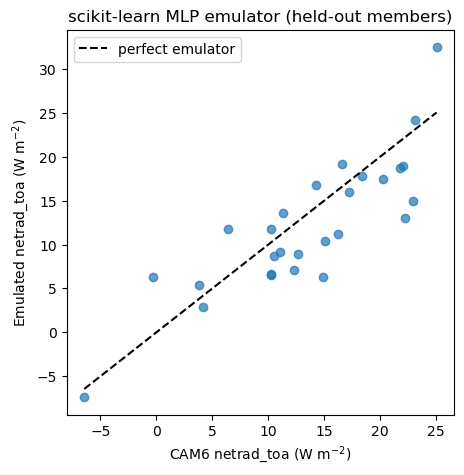

In [6]:
import matplotlib.pyplot as plt

y_pred = pipeline.predict(X_test)

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "k--", label="perfect emulator")
plt.xlabel("CAM6 netrad_toa (W m$^{-2}$)")
plt.ylabel("Emulated netrad_toa (W m$^{-2}$)")
plt.title("scikit-learn MLP emulator (held-out members)")
plt.legend()
plt.show()

Points near the dashed line are members whose top-of-atmosphere energy balance the emulator reproduced without ever running the climate model for that parameter setting.

## Building the emulator with Keras/TensorFlow

As in the notes, we would generally not use scikit-learn for a production neural network, because a deep-learning library gives us far more control. We rebuild the same emulator in **TensorFlow** with the **Keras** Sequential API.

One difference from a classification model: the target is a continuous, physical quantity spanning tens of W m$^{-2}$, so we **standardize the target too** (not just the inputs) and train with a **mean-squared-error** loss instead of cross-entropy. Standardizing `y` keeps the loss and gradients well-scaled; we invert the scaling before plotting so the numbers stay in physical units.

In [7]:
import tensorflow as tf
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Scale inputs and target using statistics from the training set only.
x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train.to_numpy().reshape(-1, 1))

def scale_x(df):  return x_scaler.transform(df)
def scale_y(s):   return y_scaler.transform(s.to_numpy().reshape(-1, 1))

Xs_train, Xs_valid, Xs_test = scale_x(X_train), scale_x(X_valid), scale_x(X_test)
ys_train, ys_valid = scale_y(y_train), scale_y(y_valid)

We create the model with the Sequential API, a stack of fully connected (`Dense`) layers. The input layer has one unit per parameter; the output layer is a single unit (one predicted climatology) with no activation, as is standard for regression.

In [8]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

n_features = Xs_train.shape[1]
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=[n_features]),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])
model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 64)                2944      


 dense_1 (Dense)             (None, 64)                4160      


 dense_2 (Dense)             (None, 1)                 65        


Total params: 7169 (28.00 KB)


Trainable params: 7169 (28.00 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


### Compiling the model
We compile with a mean-squared-error loss and the Adam optimizer, and track mean absolute error as a readable metric (in standardized units for now).

In [9]:
model.compile(loss="mse",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["mae"])

### Training and evaluating the model

In [10]:
history = model.fit(Xs_train, ys_train, epochs=200,
                    validation_data=(Xs_valid, ys_valid),
                    verbose=0)
print(f"Trained for {len(history.epoch)} epochs.")

Trained for 200 epochs.


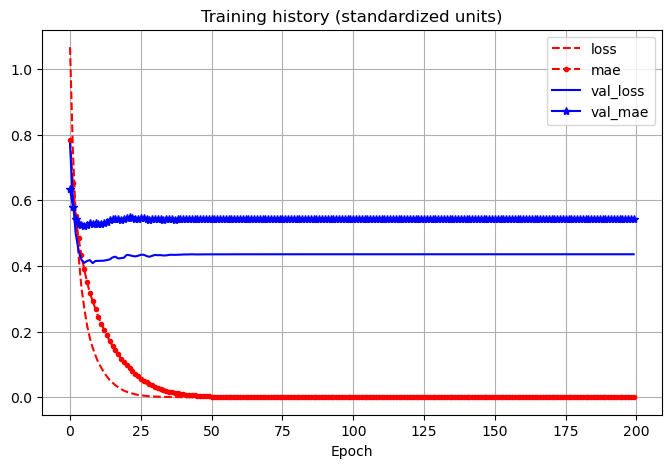

In [11]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.title("Training history (standardized units)")
plt.show()

The learning curves show the loss falling as the network fits the ensemble. Notice that the **validation loss sits above the training loss** and stops improving while the training loss keeps dropping. That gap is a sign of **overfitting**: with only ~200 training members and 45 inputs, the network has enough capacity to memorize quirks of the training runs that don't generalize to unseen ones. On a small PPE like this, some overfitting is hard to avoid, and it is one reason the held-out $R^2$ is only moderate. Now evaluate on the held-out test members and convert the predictions back to physical W m$^{-2}$:

Keras test R^2: 0.371


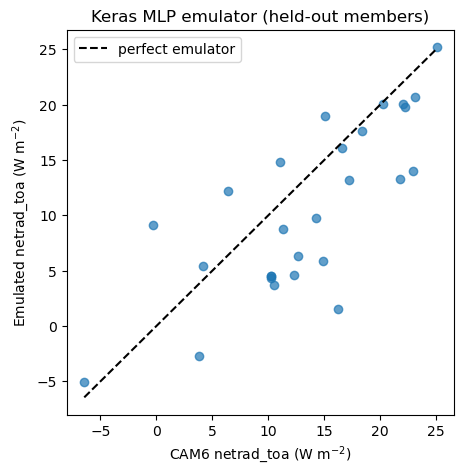

In [12]:
y_pred_keras = y_scaler.inverse_transform(model.predict(Xs_test, verbose=0)).ravel()

ss_res = np.sum((y_test.to_numpy() - y_pred_keras) ** 2)
ss_tot = np.sum((y_test.to_numpy() - y_test.mean()) ** 2)
r2_keras = 1 - ss_res / ss_tot
print(f"Keras test R^2: {r2_keras:.3f}")

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_keras, alpha=0.7)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "k--", label="perfect emulator")
plt.xlabel("CAM6 netrad_toa (W m$^{-2}$)")
plt.ylabel("Emulated netrad_toa (W m$^{-2}$)")
plt.title("Keras MLP emulator (held-out members)")
plt.legend()
plt.show()

## Using the emulator in practice: a new parameter setting

This is what makes the emulator useful. Suppose we propose a **new** set of the 45 parameters that was never run through the climate model. The emulator predicts the resulting top-of-atmosphere radiation instantly, so we can screen thousands or millions of candidate settings (to calibrate the model, or to map how output responds to the parameters) without paying for a single expensive simulation.

To imitate a genuinely unseen setting, we draw one member at random from the held-out **test** set: the network never saw it during training, so its prediction is a fair test of how the emulator would do on a brand-new proposal.

In [13]:
rng = np.random.default_rng(0)
i = rng.integers(len(X_test))
new_params = X_test.iloc[[i]]   # a 1-row, 45-column "proposed" parameter set

pred = y_scaler.inverse_transform(
    model.predict(x_scaler.transform(new_params), verbose=0))[0, 0]
truth = y_test.iloc[i]
print(f"Emulator-predicted netrad_toa: {pred:6.2f} W m^-2")
print(f"Actual CAM6 netrad_toa:        {truth:6.2f} W m^-2")

Emulator-predicted netrad_toa:   6.37 W m^-2
Actual CAM6 netrad_toa:         12.64 W m^-2


Where does this proposed setting sit relative to the rest of the ensemble? We plot the distribution of each of the 45 parameters across all CAM6 members (blue histograms) and mark the new selection with a red line. Because the proposal was itself drawn from the PPE, each red line falls somewhere inside its parameter's sampled range: a plausible combination the emulator can be trusted to interpolate.

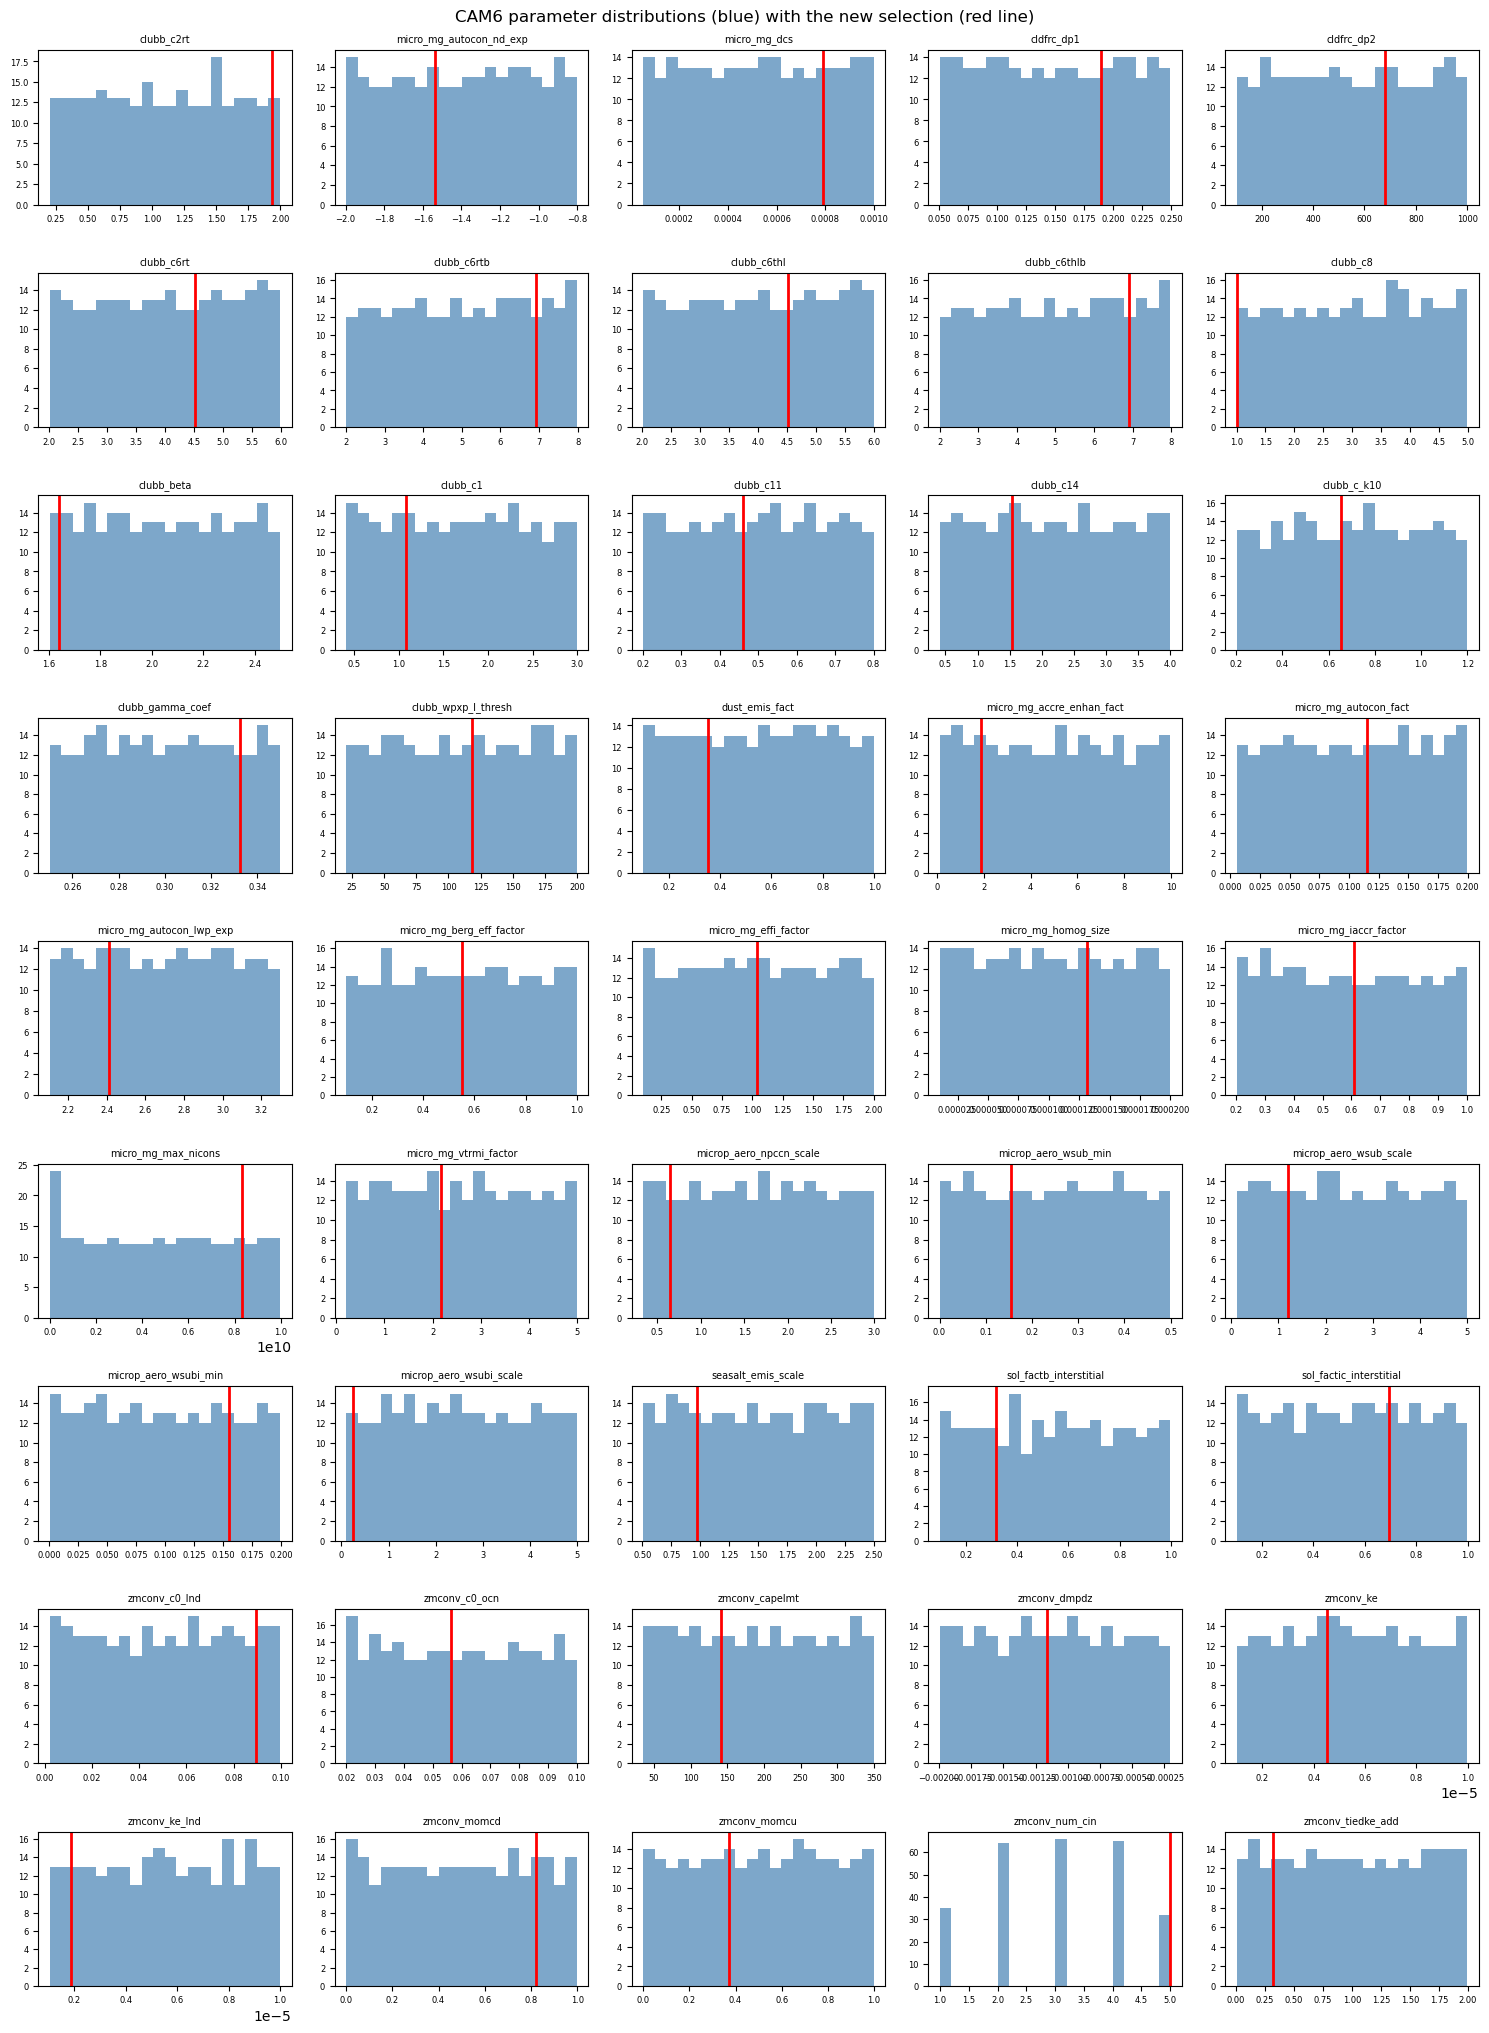

In [14]:
params = cam6_X.columns
ncols = 5
nrows = int(np.ceil(len(params) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 2.3 * nrows))
for ax, p in zip(axes.ravel(), params):
    ax.hist(cam6_X[p], bins=20, color="steelblue", alpha=0.7)
    ax.axvline(new_params[p].values[0], color="red", linewidth=2)
    ax.set_title(p, fontsize=7)
    ax.tick_params(labelsize=6)
for ax in axes.ravel()[len(params):]:
    ax.axis("off")
fig.suptitle("CAM6 parameter distributions (blue) with the new selection (red line)",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

Each red line is the proposed value of one parameter; the histogram behind it is how that parameter was sampled across the 262 runs. In a real calibration study you would sweep the red lines across these ranges, emulate `netrad_toa` (and other climatologies) for each combination in milliseconds, and keep only the settings whose emergent climate matches observations.

## The same workflow on a second model: ModelE3

The point of Yang et al. (2024) is that one emulator recipe should work across *different* climate models. NASA-GISS's **ModelE3** PPE perturbs its own set of ~45 parameters over 751 members. We reuse the exact same steps (load, split, scale, train) with nothing model-specific hard-coded, wrapping them in a small function so the workflow is obviously identical.

In [15]:
modele_X, modele_y = load_ppe("modele3")
print("ModelE3 parameters:", modele_X.shape)
print("ModelE3 climatologies:", modele_y.shape)

ModelE3 parameters: (751, 45)
ModelE3 climatologies: (751, 36)


In [16]:
def train_keras_emulator(X, y, epochs=200, seed=42):
    """Train a Keras MLP emulator for one climatology; return (r2, y_test, y_pred)."""
    X_tr_full, X_te, y_tr_full, y_te = train_test_split(
        X, y, test_size=0.1, random_state=seed)
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr_full, y_tr_full, test_size=0.1, random_state=seed)

    xs = StandardScaler().fit(X_tr)
    ys = StandardScaler().fit(y_tr.to_numpy().reshape(-1, 1))
    sx = lambda d: xs.transform(d)
    sy = lambda s: ys.transform(s.to_numpy().reshape(-1, 1))

    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)
    m = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=[X.shape[1]]),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1),
    ])
    m.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(), metrics=["mae"])
    m.fit(sx(X_tr), sy(y_tr), epochs=epochs,
          validation_data=(sx(X_va), sy(y_va)), verbose=0)

    y_pred = ys.inverse_transform(m.predict(sx(X_te), verbose=0)).ravel()
    ss_res = np.sum((y_te.to_numpy() - y_pred) ** 2)
    ss_tot = np.sum((y_te.to_numpy() - y_te.mean()) ** 2)
    return 1 - ss_res / ss_tot, y_te, y_pred

ModelE3 netrad_toa test R^2: 0.573


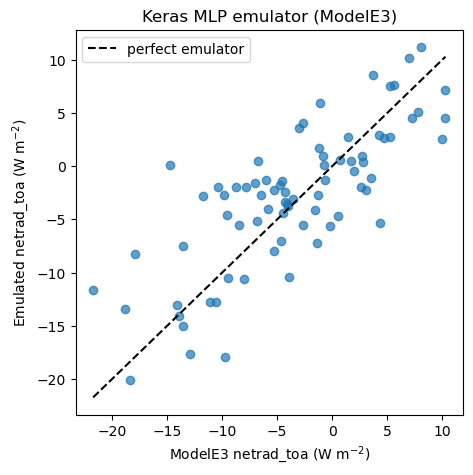

In [17]:
r2_modele, y_te_m, y_pred_m = train_keras_emulator(modele_X, modele_y["netrad_toa"])
print(f"ModelE3 netrad_toa test R^2: {r2_modele:.3f}")

plt.figure(figsize=(5, 5))
plt.scatter(y_te_m, y_pred_m, alpha=0.7)
lims = [y_te_m.min(), y_te_m.max()]
plt.plot(lims, lims, "k--", label="perfect emulator")
plt.xlabel("ModelE3 netrad_toa (W m$^{-2}$)")
plt.ylabel("Emulated netrad_toa (W m$^{-2}$)")
plt.title("Keras MLP emulator (ModelE3)")
plt.legend()
plt.show()

## Wrap-up

We built a neural-network **emulator** of two climate model PPEs, predicting an emergent climate output (top-of-atmosphere net radiation) directly from the model's tunable parameters: first with a scikit-learn `MLPRegressor`, then with a Keras/TensorFlow MLP, and finally reusing the identical pipeline on a second climate model.

A few things worth remembering:

- **Emulation is regression.** The switch from a *classifier* (like the Iris example in the notes) to an emulator is mostly swapping the last layer, the loss (MSE), and the metric ($R^2$); the ANN machinery is the same.
- **Scaling matters more here.** The parameters span many orders of magnitude and the target is a physical quantity, so we standardize *both* inputs and target.
- **Data is sparse.** A few hundred expensive runs over ~45 parameters is a hard regime; the moderate $R^2$ and the training/validation gap reflect that, and it is exactly why Yang et al. (2024) argue for simpler, more interpretable emulators (SAGE) alongside neural networks. A natural next step is to emulate other climatologies (`sw_cre`, `albedo`, `prec`) or all of them at once with a multi-output network.


## Try it yourself

Use the code above as a starting point for a few short experiments:

1. **Emulate a different output.** Re-run the scikit-learn emulator with `target` set to `"sw_cre"` (shortwave cloud radiative effect) or `"albedo"` instead of `"netrad_toa"`. Which climatology is easiest for the MLP to predict (highest validation $R^2$), and which is hardest?
2. **Change the network size.** Try `hidden_layer_sizes=[16]`, `[64, 64]`, and `[128, 128, 128]` in the `MLPRegressor`. Does a bigger network always give a better validation $R^2$ on this small dataset? What does that tell you about overfitting?
3. **Train longer and watch the gap.** Increase the Keras `epochs` to 1000 and re-plot the training history. Does the gap between the training and validation loss grow? What does a widening gap mean for how well the emulator will generalize to new parameter settings?
4. **Compare the two models.** Run `train_keras_emulator` on the CAM6 and ModelE3 PPEs for the same output (`netrad_toa`). Which PPE is easier to emulate, and can you think of a reason why (hint: compare the number of ensemble members)?
